<center><br><font size=10>HW4</font><br>
<font size=6>SVM & Decision Trees</font>
<br><br>
<b>Introduction to Machine Learning – Digital Sciences for High-Tech</b>
<br><br>
<br><i>Spring 2025</i></center>

The answered notebook should be submitted in the following format: HW4_{id}.ipynb

# Instructions
1. Write all code within the functions
2. Make sure to **return** the solution in every function
3. Don't be afraid to search the internet for help
4. The answered notebook should be submitted in the following format: HW4_{id}.ipynb
5. **Before submission reset kernel and run all, make sure there are no running errors!!!**
6. When needed to give an answer, don't print it unless you were asked to, just write it at the end of the cell and you should see the output as it is.
7. Do not change variable names or tests. If you are asked to answer with a certain variable, use it and do not use a different name. Do not change the given tests if there are any. You can add new tests as you'd like, but leave the given test in the code as it is.
8. When asked to answer theoretically (without implementing a code), answer in the given markdown "answer here" cell

## Import libraries
You are allowed to use these libraries only. Other libraries from sklearn are not allowed without permission! However, feel free to ask for permission from course staff.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_validate
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import auc, roc_auc_score, mean_squared_error
from sklearn.metrics import roc_curve
from IPython.display import Image
import os
import time

# Utility functions
functions that may assist you during this exercise. feel free to use them where you find them neccessary.

In [7]:
def plot_svm_decision_boundary(clf,margins=False) -> None:
    """
    Plots Decision boundries for trained svm classifier -> after calling this function use plt.show()
    clf: sklearn svm object after training (clf.fit())
    margins: boolean parameter to display the margins (False by default)
    """
    # plot the decision function
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    if margins:
        # plot decision boundary and margins
        ax.contour(XX, YY, Z, colors='k',levels=[-1,0,1], alpha=0.5,
                linestyles=['--', '-', '--'])
    else:
        # plot decision boundary without margins
        ax.contour(XX, YY, Z, colors='k', levels=[0], alpha=0.5,
                linestyles=['-'])
        
        # plot decision boundary without margins
        ax.contour(XX, YY, Z, colors='k',levels=1, alpha=0.5,
                linestyles=['-'])
    
def load_housing_data() -> tuple([pd.DataFrame,pd.Series]):
    assert os.path.exists('data_part2.csv'), "data.csv file must be in the same folder as the notebook!"
    housing_prices = pd.read_csv('data_part2.csv')
    y = housing_prices.price > housing_prices.price.mean()
    X = housing_prices.drop(columns=['price', 'date', 'id'])
    return X, y

# Part 1: SVM

#### Reading data

In [8]:
df = pd.read_csv('data_part1.csv')
X = df.iloc[:,:-1].values
y = df.iloc[:,-1]

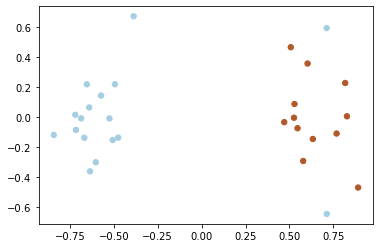

In [9]:
#Plotting the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=29, cmap=plt.cm.Paired)
plt.show()

## a. Linear SVM
Use Linear SVM (SVM with linear kernel) and penalty C=1.  Plot the decision boundary and the margin. <br>
Answer the following question and explain your answer:<br>
How many support vectors do we get in this case?

In [ ]:
#TODO: your code here
clf = None
#for plotting
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)
plot_svm_decision_boundary(clf,True)
plt.show()

Question: How many support vectors do we get in this case? <br>
TODO Your Answer:

## b. Penalty analysis for rbf kernel

Use SVM with RBF kernel. The slack penalty 𝐶 will determine the location of the separating hyperplane.<br>
    1. Where would the decision boundary be for very small values of 𝐶 (i.e.,𝐶 ≈ 0)? Plot the decision boundary. Justify your answer with words!<br>
    2. Where would the decision boundary be for very large values of 𝐶 (i.e., 𝐶 → ∞)? Plot the decision boundary. Justify your answer with words!<br>

In [ ]:
# Use this C list to answer questions above
Cs=[1,1000]
for c in Cs:
    clf = None # TODO: your code here
    #for plotting
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)
    plot_svm_decision_boundary(clf,True)
    plt.show()

TODO Answer with words below:

## c. Choosing kernel hyperparameter for SVM

#### Creating data

In [12]:
# we generate 1000 samples with 2 features
X,y = datasets.make_circles(n_samples=1000, factor=.5, noise=.15, random_state=6)

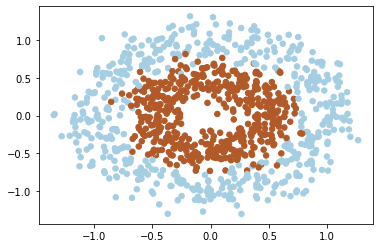

In [13]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)
plt.show()

#### spliting data into train & Validation

In [14]:
X_train, X_Validation, y_train, y_Validation = train_test_split(X, y, test_size=0.25,random_state = 42,shuffle = True)

### Your mission:
For each k value in kernels:
1. Run SVM with k kernel on the train data (with C=1)

2. Plot all the hyperplane & X values on the graph - train and validation. (Use utility functions the plot). **Plot train and validation points in the same graph**.

3. Use the validation data to calculate the Accuracy for each kernel.

4. add a title that contains the kernel and the accuracy in the following format:<br>
"Hyperplane with kernel=linear and Acc=0.65" (the kernel and numbers are just for example).

In addition print: What is the optimal kernel for this dataset?

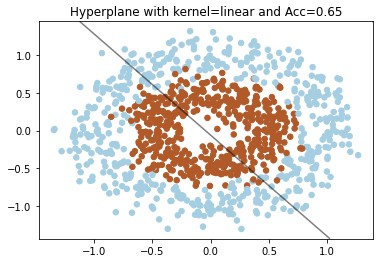

In [15]:
# Example plot
Image(filename='example_for_part1c.jpg') 

In [16]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

In [19]:
#TODO: your code here
chosen_k = None
print("The optimal kernel is: ", chosen_k)
# you may encounter a warning, you can ignore it

The optimal kernel is:  None


# Part 2: Decision Trees

## a. Decision tree loss function: <br>
Consider the Gini index, classification error, and entropy in a simple binary classification setting. <br>
Create a single plot that displays each of these quantities as a function of $\hat{p}_{m1}$ <br> which is the probability of class 1 in a tree node $m$ (if there is 1 `1` and 9 `0` then it is $\hat{p}_{m1}=0.1$). <br>
For `entropy`, use 0.5*entropy, instead of regular entropy formula. <br>
Hint: the output should look like the one from the lecture

In [ ]:
p = np.arange(0, 1, 0.001)  # probabilities

#TODO: get required values
# for classification, calssify by the maximum probability
classification_error = None

# unnormalized gini index
gini_index = None

# use only non zero values (p[1:]) to avoid an error for log(0)
# set the entropy for p=0 to 0
entropy = None

# plot
plt.plot(p, classification_error, label='classification error')
plt.plot(p, gini_index, label='gini index')
plt.plot(p, entropy, label='entropy')
plt.legend()
plt.xlabel('class 1 probability')
plt.ylabel('Loss function value')
plt.show()

## b. The Bias-Variance Tradeoff for Decision Tree Regressor
Demonstrate the bias variance tradeoff using hyperparameter selection in a Decision Tree Regressor, for the diabetes dataset.

### Instructions: 
- select one hyper-parameter to change that influences the bias variance tradeoff in Decision Tree, while setting all other parameters constant as you wish. for more information about Decision Tree Regressor parameters [see documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)
- **plot** train and validation mse according to your chosen parameter.
- explain why this demonstrates the bias variance tradeoff and how can we see it in your results.
- explain what do you think is the best value for this parameter in this experiment and why.
- max Runtime: 2 minutes
- use random_state=0 in the DecisionTreeRegressor constructor for reproducability.

In [20]:
diabetes_X_df, diabetes_y = datasets.load_diabetes(return_X_y=True, as_frame=True)
X_dia_train, X_dia_val, y_dia_train, y_dia_val = train_test_split(diabetes_X_df, diabetes_y, test_size = 0.2, random_state = 42)

In [ ]:
t0 = time.time() # for Runtime measurement
#TODO: your code here
print(f'Runtime: {round(time.time()-t0,2)} seconds')

Question: why this demonstration explains the bias variance tradeoff and how can we see it in your results? <br>
TODO your answer: 

Question: what do you think is the best value for this parameter and why? <br>
TODO your answer: 

## c. Using Random Forest Classifier

In [ ]:
X_bos, y_bos = load_housing_data()
X_bos_train, X_bos_test, y_bos_train, y_bos_test = train_test_split(X_bos, y_bos, test_size = 0.8, random_state = 42)
#Notice we take a small training set - this is only for exercise purposes so you can run the code in less than 10 minutes.

### c1. Finding hyperparameters 
Run Random Forest Classifier on the train data, by using K-fold cross-validation to tune and search for the best **hyper parameters** values with respect to AUC measure.<br>
- We suggest using `GridSearchCV` function. [Read documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

- You must get training AUC greater than 0.94 (You should limit the search to max 200 n_estimators).

- Maximun run time: 10 minutes.

- use random_state=0 in the RandomForestClassifier constructor for reproducability.

In [ ]:
t0 = time.time() # for Runtime measurement
#TODO: Write your code here, define paramaters to search over and their values. Then find the best set of parameter values to train the model on. 
# Example: {param1: [10,20,30], param2: [2,4,7]}
print(f'Runtime: {round(time.time()-t0,2)} seconds')

In [ ]:
#TODO: print requested values
best_params = None
best_score = None
print(f'Best Params: {best_params} \n')
print(f'Validation AUC score for best params: {best_score}')

In [ ]:
#TODO: Print test AUC
test_auc = None
print (f"test AUC: {test_auc}")

### c2. Feature Importance
Plot a graph of the features importance for your chosen model. what are the TOP 5 important features? can you give intuition to why would they be indicative?

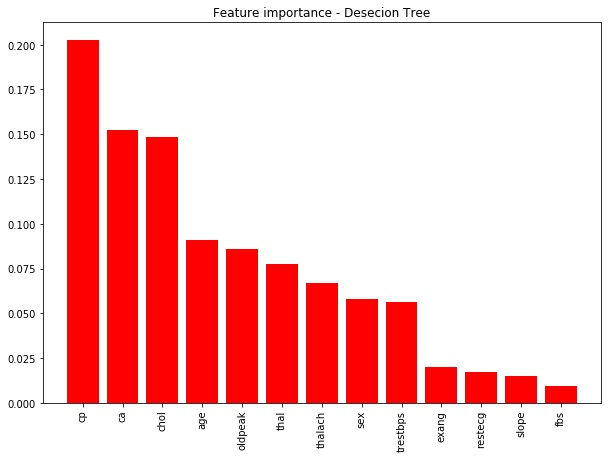

In [21]:
# Example plot
Image(filename='example_part2c.jpg') 

In [ ]:
# TODO: plot feature importance graph

Question: what are the TOP 5 important features? can you give intuition to why would they be indicative? <br>
TODO Answer:

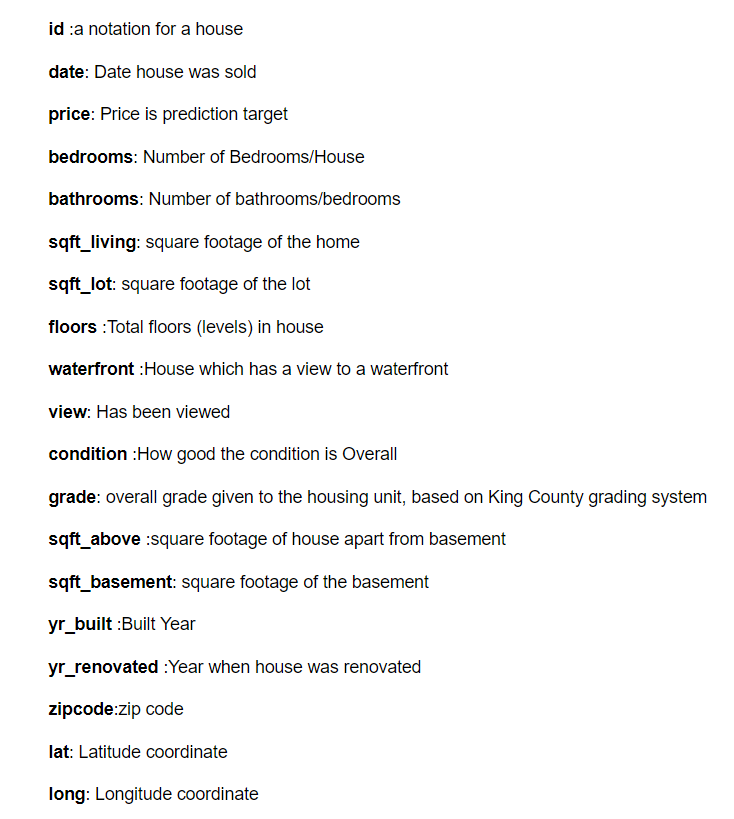

In [24]:
# feature explanations
Image(filename='feature_explanations.png') 

what are the TOP 5 important features? can you give intuition to why would they be indicative(Notice that sqft is squared feet and yr is year)? 

Write your answer here: